# Notebook長くなっていろいろめんどくなってきた 工事したい

### original 実行に時間がかかる

Total samples: 314159017


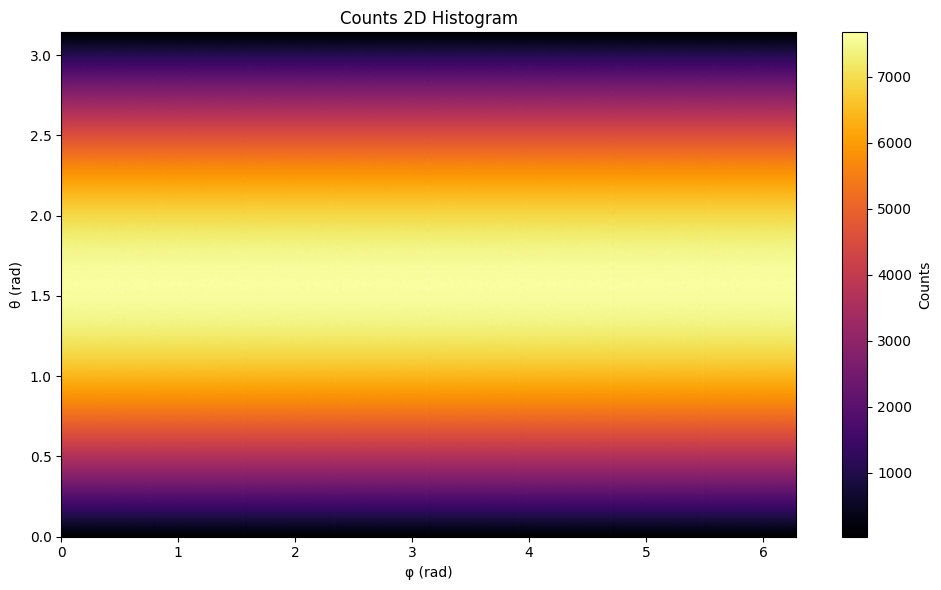

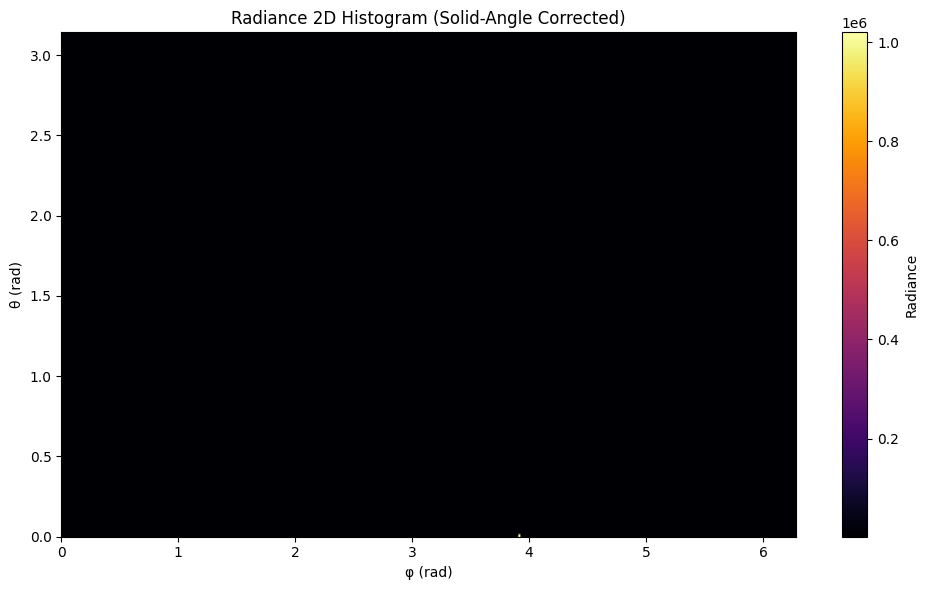

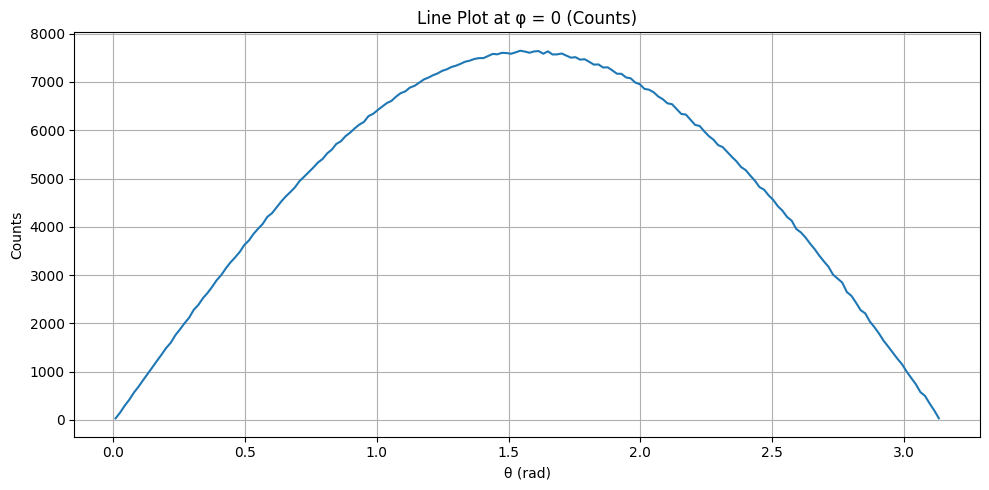

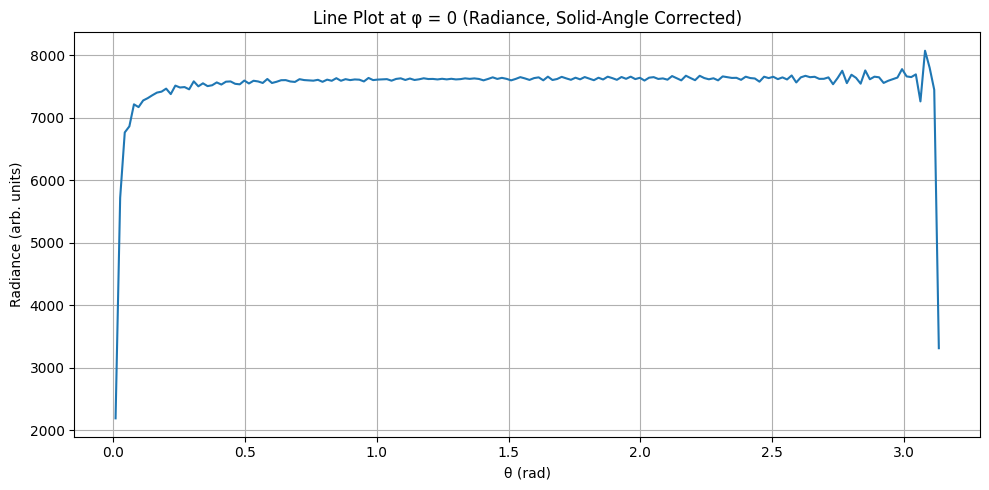

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 基本パラメータ
# ----------------------------------------
R = 1.0
step = 0.0001
xs = np.arange(-R, R+step, step)
ys = np.arange(-R, R+step, step)

d = np.array([0.0, 0.0, -1.0])  # 入射方向
Z0 = 1000.0

theta_list = []
phi_list = []

# ----------------------------------------
# 光線追跡
# ----------------------------------------
for x in xs:
    for y in ys:
        p0 = np.array([x, y, Z0])

        a = np.dot(d, d)
        b = 2 * np.dot(p0, d)
        c = np.dot(p0, p0) - R*R
        D = b*b - 4*a*c

        if D < 0:
            continue

        t = (-b - np.sqrt(D)) / (2*a)
        if t < 0:
            continue

        p = p0 + t * d
        n = p / np.linalg.norm(p)
        r = d - 2*np.dot(d, n)*n
        r /= np.linalg.norm(r)

        rx, ry, rz = r
        theta = np.arccos(rz)
        phi = np.arctan2(ry, rx)
        if phi < 0:
            phi += 2*np.pi

        theta_list.append(theta)
        phi_list.append(phi)

theta_arr = np.array(theta_list)
phi_arr = np.array(phi_list)

# θ = π の発散点を除外
epsilon = 1e-6
mask = theta_arr < (np.pi - epsilon)
theta_arr = theta_arr[mask]
phi_arr   = phi_arr[mask]

print("Total samples:", len(theta_arr))


# ------------------------------------------------------
# ① θ–φ 2D ヒストグラム（通常）
# ------------------------------------------------------
phi_bins = 360
theta_bins = 180

hist_count, phi_edges, theta_edges = np.histogram2d(
    phi_arr, theta_arr,
    bins=[phi_bins, theta_bins]
)

plt.figure(figsize=(10, 6))
plt.imshow(hist_count.T, origin='lower',
           extent=[0, 2*np.pi, 0, np.pi],
           aspect='auto', cmap='inferno')
plt.xlabel("φ (rad)")
plt.ylabel("θ (rad)")
plt.title("Counts 2D Histogram")
plt.colorbar(label="Counts")
plt.tight_layout()
plt.show()


# ------------------------------------------------------
# ② 立体角補正（weights = 1/sinθ）
# ------------------------------------------------------
sin_theta = np.sin(theta_arr)
sin_theta[sin_theta < 1e-6] = 1e-6
weights = 1.0 / sin_theta

hist_radiance, _, _ = np.histogram2d(
    phi_arr, theta_arr,
    bins=[phi_bins, theta_bins],
    weights=weights
)

plt.figure(figsize=(10, 6))
plt.imshow(hist_radiance.T, origin='lower',
           extent=[0, 2*np.pi, 0, np.pi],
           aspect='auto', cmap='inferno')
plt.xlabel("φ (rad)")
plt.ylabel("θ (rad)")
plt.title("Radiance 2D Histogram (Solid-Angle Corrected)")
plt.colorbar(label="Radiance")
plt.tight_layout()
plt.show()


# ------------------------------------------------------
# ③ φ = 0 における line plot
# ------------------------------------------------------

# φ bin の中央値
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])

# φ=0 に最も近い bin を選ぶ
phi0_index = np.argmin(np.abs(phi_centers - 0))

# θ bin 中央
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])

# φ=0 の列のカウント
line_counts = hist_count[phi0_index, :]
line_radiance = hist_radiance[phi0_index, :]

# プロット（カウント）
plt.figure(figsize=(10, 5))
plt.plot(theta_centers, line_counts)
plt.xlabel("θ (rad)")
plt.ylabel("Counts")
plt.title("Line Plot at φ = 0 (Counts)")
plt.grid(True)
plt.tight_layout()
plt.show()

# プロット（立体角補正：輝度）
plt.figure(figsize=(10, 5))
plt.plot(theta_centers, line_radiance)
plt.xlabel("θ (rad)")
plt.ylabel("Radiance (arb. units)")
plt.title("Line Plot at φ = 0 (Radiance, Solid-Angle Corrected)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Last updated in 20260121 from below (AyutoK)

### 1d

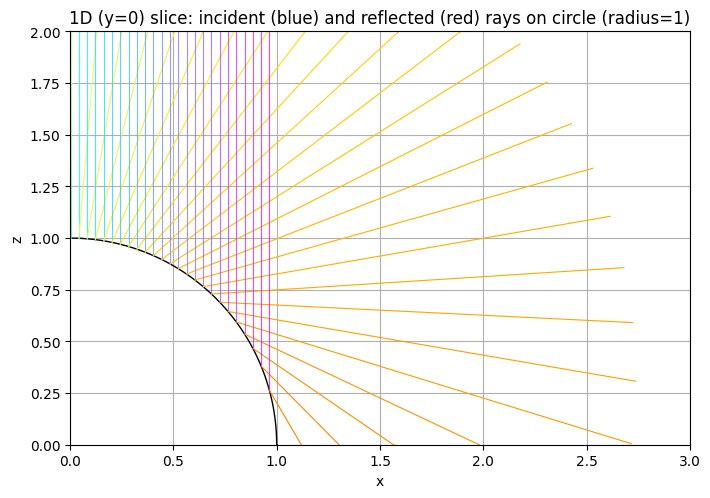

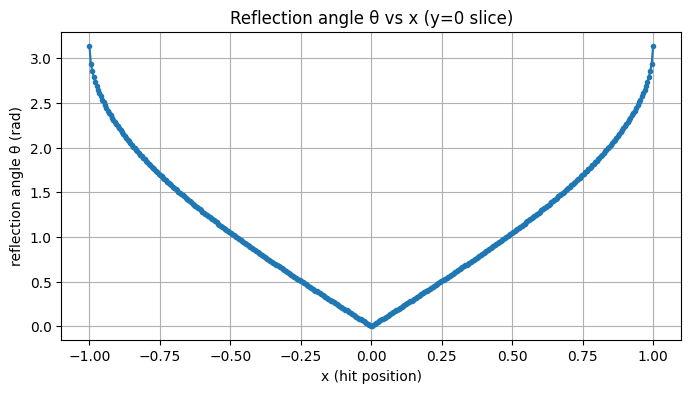

In [ ]:
# 新しいセル: x方向のみの一次元プロット（x-y平面の断面、y=0）
import numpy as np
import matplotlib.pyplot as plt

R = 1.0
Z0 = 1000.0
d = np.array([0.0, 0.0, -1.0])

# サンプリング点（必要に応じて N を増減）
N = 400
xs = np.linspace(-R, R, N)

hits = []
ref_dirs = []
p_hits = []
p0s = []

for x in xs:
    p0 = np.array([x, 0.0, Z0])
    a = np.dot(d, d)
    b = 2 * np.dot(p0, d)
    c = np.dot(p0, p0) - R*R
    D = b*b - 4*a*c
    if D < 0:
        continue
    t = (-b - np.sqrt(D)) / (2*a)
    if t < 0:
        continue
    p = p0 + t * d
    n = p / np.linalg.norm(p)
    r = d - 2*np.dot(d, n)*n
    r = r / np.linalg.norm(r)
    # 保存
    hits.append(x)
    ref_dirs.append(r)
    p_hits.append(p)
    p0s.append(p0)

# プロット: 円（球の断面）と入射/反射線
fig, ax = plt.subplots(figsize=(8,6))

# 円（x-z平面）
theta = np.linspace(0, 2*np.pi, 400)
circle_x = R * np.cos(theta)
circle_z = R * np.sin(theta)
ax.plot(circle_x, circle_z, 'k', linewidth=1)

# カラーマップ
cmap_in = plt.get_cmap("cool")
cmap_ref = plt.get_cmap("Wistia")


# 代表的な線をプロット（プロット数制限）
L = 2.0 * R  # 反射線の長さスケール
step_plot = max(1, len(p_hits)//50)  # 多すぎないように間引き
for i in range(len(p_hits)//2, len(p_hits), step_plot):

    ic = (i - len(p_hits)//2) / (len(p_hits)//2)

    p0 = p0s[i]
    p = p_hits[i]
    r = ref_dirs[i]
    # 入射線（p0 -> p）
    ax.plot([p0[0], p[0]], [p0[2], p[2]], color=cmap_in(int(ic * cmap_in.N)), alpha=0.8, linewidth=0.8)
    # 反射線（p -> p + L * r）
    ax.plot([p[0], p[0] + L*r[0]], [p[2], p[2] + L*r[2]], color=cmap_ref(int(ic * cmap_ref.N)), alpha=1, linewidth=0.8)

ax.set_aspect('equal')
ax.set_xlim(0, 3*R)
ax.set_ylim(0, 2*R)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_title('1D (y=0) slice: incident (blue) and reflected (red) rays on circle (radius=1)')
ax.grid(True)
plt.show()

# 反射角 θ（z軸からの角度）を x に対してプロット
xs_hit = np.array(hits)
rz = np.array([r[2] for r in ref_dirs])
theta_ref = np.arccos(np.clip(rz, -1.0, 1.0))

plt.figure(figsize=(8,4))
plt.plot(xs_hit, theta_ref, '.-')
plt.xlabel('x (hit position)')
plt.ylabel('reflection angle θ (rad)')
plt.title('Reflection angle θ vs x (y=0 slice)')
plt.grid(True)
plt.show()

### R=一定値における角度分布

Total samples: 10001


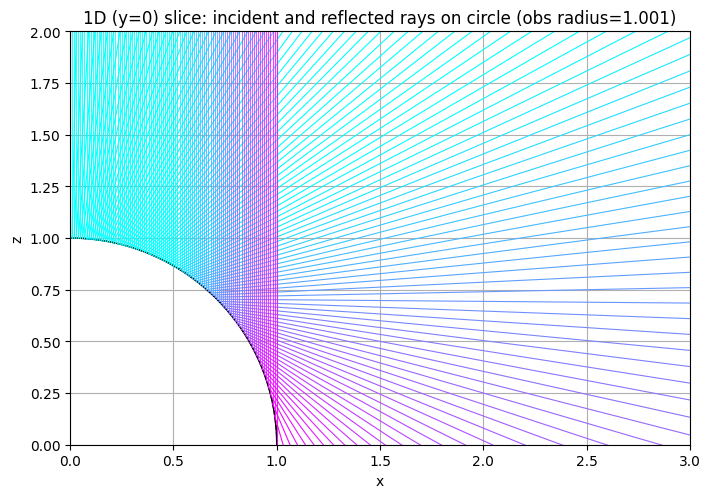

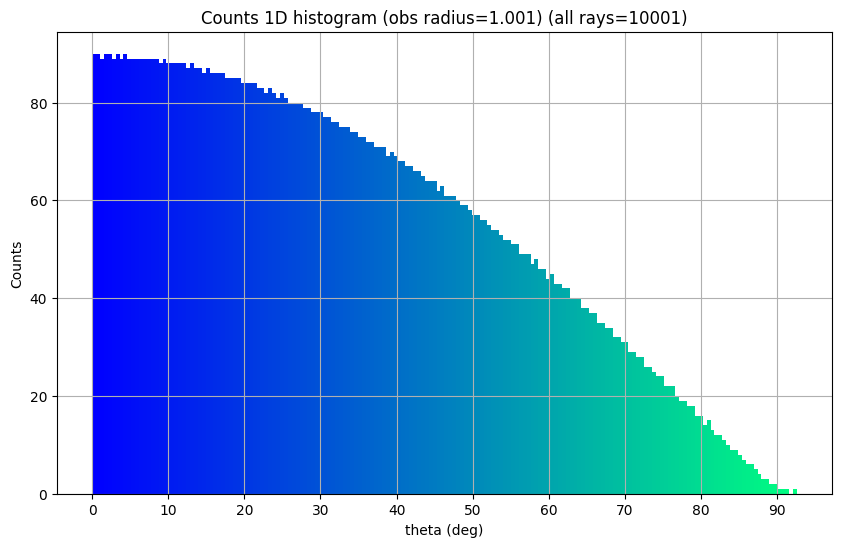

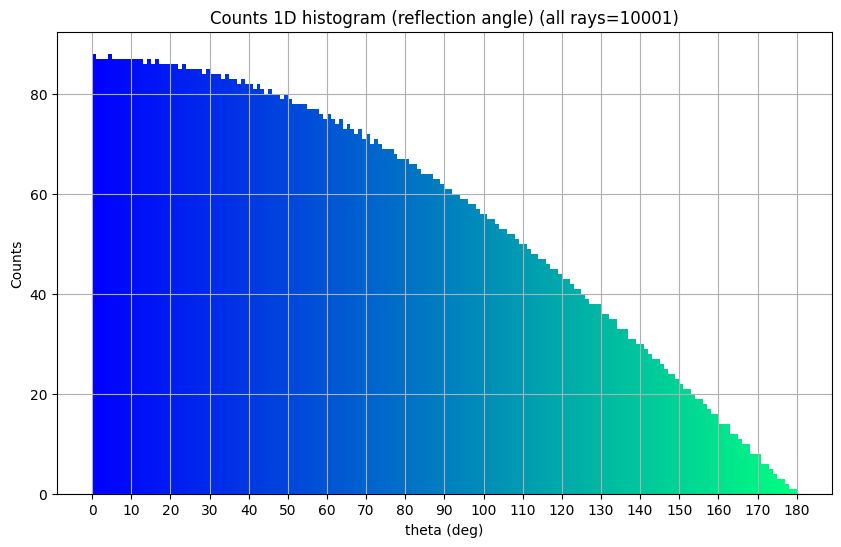

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fp = "./output/" # 画像出力先

# ----------------------------------------
# 基本パラメータ
# ----------------------------------------
R = 1.0
step = 0.0001
xs = np.arange(0, R+step, step)

d = np.array([0.0, 0.0, -1.0])  # 入射方向
Z0 = 1000.0

R2 = 1.001 # 観測点の半径

theta_list = []
theta_ref_list = [] # 反射角
phi_list = []
p0s = []
p2s = []
ref_dirs = []

ts = []

p_hits = []

rs = []

# ----------------------------------------
# 光線追跡
# ----------------------------------------

y = 0.0 # 今は二次元 三次元を見据えて

for x in xs:
    p0 = np.array([x, y, Z0])

    a = np.dot(d, d)
    b = 2 * np.dot(p0, d)
    c = np.dot(p0, p0) - R*R
    D = b*b - 4*a*c

    if D < 0:
        continue

    t = (-b - np.sqrt(D)) / (2*a)
    if t < 0:
        continue

    p = p0 + t * d  # 反射点の位置ベクトル
    n = p / np.linalg.norm(p)
    r = d - 2*np.dot(d, n)*n
    r /= np.linalg.norm(r) # 反射光の方向ベクトル(外側へ向かう方向を正)
    th_r = np.arccos(r[2])
    theta_ref_list.append(np.degrees(th_r))
    rs.append(r)

    ts.append(t)

    a2 = np.dot(r, r)
    b2 = 2 * np.dot(p, r)
    c2 = np.dot(p, p) - R2*R2
    D2 = b2*b2 - 4*a2*c2

    if D2 < 0:
        continue

    t2 = (-b2 + np.sqrt(D2)) / (2*a2)
    if t2 < 0:
        continue

    p2 = p + t2 * r # 観測球面との交点
    p2_n = p2 / np.linalg.norm(p2)  # 単位ベクトル化

    theta = np.arccos(p2_n[2])
    phi = np.arctan2(p2_n[1], p2_n[0])
    if phi < 0:
        phi += 2*np.pi

    theta_deg = np.degrees(theta)
    phi_deg = np.degrees(phi)

    p0s.append(p0)
    p2s.append(p2)
    p_hits.append(p)
    ref_dirs.append(r)
    theta_list.append(theta_deg)
    phi_list.append(phi_deg) # y=0では当然0 or pi

theta_arr_r2 = np.array(theta_list)
theta_ref_arr = np.array(theta_ref_list)
phi_arr_r2 = np.array(phi_list)

samp = len(theta_arr_r2)

print("Total samples:", samp)

# ------------------------------------------------------
# 描画の準備
# ------------------------------------------------------

fig, ax = plt.subplots(figsize=(8,6))

# 円（x-z平面）
theta = np.linspace(0, 2*np.pi, 400)
circle_x = R * np.cos(theta)
circle_z = R * np.sin(theta)
circle_x2 = R2 * np.cos(theta)
circle_z2 = R2 * np.sin(theta)
ax.plot(circle_x, circle_z, 'k', linewidth=1)
ax.plot(circle_x2, circle_z2, 'k', linewidth=1, linestyle="--")

# カラーマップ
cmap_in = plt.get_cmap("cool")
cmap_ref = plt.get_cmap("cool")

cmap_hist = plt.get_cmap("winter")

# ------------------------------------------------------
# 描画1:光線の図示
# ------------------------------------------------------

L = 3.0 * R  # 反射線の長さスケール
step_plot = max(1, len(xs)//100)  # 多すぎないように間引き
for i in range(0, len(xs), step_plot):

    ic = (i - len(p_hits)//2) / (len(p_hits)//2)

    p0 = p0s[i]
    p = p_hits[i]
    r = ref_dirs[i]
    # 入射線（p0 -> p）
    ax.plot([p0[0], p[0]], [p0[2], p[2]], color=cmap_in(int(ic * cmap_in.N)), alpha=0.8, linewidth=0.8)
    # 反射線（p -> p + L * r）
    ax.plot([p[0], p[0] + L*r[0]], [p[2], p[2] + L*r[2]], color=cmap_ref(int(ic * cmap_ref.N)), alpha=1, linewidth=0.8)

ax.set_aspect('equal')
ax.set_xlim(0, 3*R)
ax.set_ylim(0, 2*R)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_title(f'1D (y=0) slice: incident and reflected rays on circle (obs radius={R2})')
ax.grid(True)

plt.savefig(fp + f"inc_ref_rays_R{R2}.png")
plt.show()

# ------------------------------------------------------
# 描画2:角度分布
# ------------------------------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

ax.grid()
ax.set_xticks(np.arange(0,181,10))

ax.set_title(f"Counts 1D histogram (obs radius={R2}) (all rays={samp})")
ax.set_xlabel("theta (deg)")
ax.set_ylabel("Counts")
n, bins, patches = ax.hist(theta_arr_r2, bins=180, color="blue")
for i in range(len(patches)):
    patches[i].set_facecolor(cmap_hist(i / len(patches)))

plt.savefig(fp + f"theta_hist_R{R2}.png")
plt.show()

# ------------------------------------------------------
# 描画3:反射角分布 (無限遠観測と漸近するはず)
# ------------------------------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)

ax.grid()
ax.set_xticks(np.arange(0,181,10))

ax.set_title(f"Counts 1D histogram (reflection angle) (all rays={samp})")
ax.set_xlabel("theta (deg)")
ax.set_ylabel("Counts")
n, bins, patches = ax.hist(theta_ref_arr, bins=180, color="blue")
for i in range(len(patches)):
    patches[i].set_facecolor(cmap_hist(i / len(patches)))

plt.savefig(fp + f"theta_hist_reflection.png")
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

fp = "./output/" # 画像出力先

# ----------------------------------------
# 基本パラメータ
# ----------------------------------------
R = 1.0
step = 0.0001
xs = np.arange(0, R+step, step)

d = np.array([0.0, 0.0, -1.0])  # 入射方向
Z0 = 1000.0

R2 = 20000 # 観測点の半径

# ----------------------------------------
# 光線追跡
# ----------------------------------------

y = 0.0 # 今は二次元 三次元を見据えて

def ref_rays_count(R2, xs, d, Z0, R, y=0.0, print_info=True):

    theta_list = []
    phi_list = []
    p0s = []
    p2s = []
    ref_dirs = []

    ts = []

    p_hits = []

    rs = []

    for x in xs:
        p0 = np.array([x, y, Z0])

        a = np.dot(d, d)
        b = 2 * np.dot(p0, d)
        c = np.dot(p0, p0) - R*R
        D = b*b - 4*a*c

        if D < 0:
            continue

        t = (-b - np.sqrt(D)) / (2*a)
        if t < 0:
            continue

        p = p0 + t * d  # 反射点の位置ベクトル
        n = p / np.linalg.norm(p)
        r = d - 2*np.dot(d, n)*n
        r /= np.linalg.norm(r) # 反射光の方向ベクトル(外側へ向かう方向を正)
        rs.append(r)

        ts.append(t)

        a2 = np.dot(r, r)
        b2 = 2 * np.dot(p, r)
        c2 = np.dot(p, p) - R2*R2
        D2 = b2*b2 - 4*a2*c2

        if D2 < 0:
            continue

        t2 = (-b2 + np.sqrt(D2)) / (2*a2)
        if t2 < 0:
            continue

        p2 = p + t2 * r # 観測球面との交点
        p2_n = p2 / np.linalg.norm(p2)  # 単位ベクトル化

        theta = np.arccos(p2_n[2])
        phi = np.arctan2(p2_n[1], p2_n[0])
        if phi < 0:
            phi += 2*np.pi

        theta_deg = np.degrees(theta)
        phi_deg = np.degrees(phi)

        p0s.append(p0)
        p2s.append(p2)
        p_hits.append(p)
        ref_dirs.append(r)
        theta_list.append(theta_deg)
        phi_list.append(phi_deg) # y=0では当然0 or pi

    theta_arr_r2 = np.array(theta_list)
    phi_arr_r2 = np.array(phi_list)

    samp = len(theta_arr_r2)

    if print_info:
        print("Total samples:", samp)

    return theta_arr_r2, phi_arr_r2, p0s, p2s, p_hits, ref_dirs

def abs_check_r2(R2, p2s):
    p2s_abs = np.array(np.linalg.norm(p2s, axis=1))
    abs_true = np.full(len(p2s), R2)

    ths = 1e-6

    abs_check = p2s_abs - abs_true

    return np.all(np.abs(abs_check) < ths)

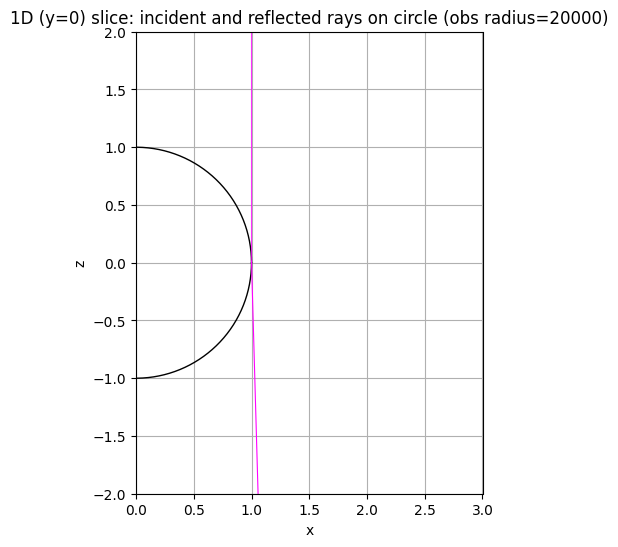

[ 1.00082684  0.         -0.01861804]
91.06573074637319


In [5]:
fig, ax = plt.subplots(figsize=(8,6))

theta = np.linspace(0, 2*np.pi, 400)
circle_x = R * np.cos(theta)
circle_z = R * np.sin(theta)
circle_x2 = R2 * np.cos(theta)
circle_z2 = R2 * np.sin(theta)
ax.plot(circle_x, circle_z, 'k', linewidth=1)
ax.plot(circle_x2, circle_z2, 'k', linewidth=1, linestyle="--")

L = 3.0 * R  # 反射線の長さスケール
step_plot = max(1, len(xs)//100)  # 多すぎないように間引き

p0 = p0s[-2]
p = p_hits[-2]
r = ref_dirs[-2]
p2 = p2s[-2]
# 入射線（p0 -> p）
ax.plot([p0[0], p[0]], [p0[2], p[2]], color=cmap_in(int(ic * cmap_in.N)), alpha=0.8, linewidth=0.8)
# 反射線（p -> p + L * r）
ax.plot([p[0], p[0] + L*r[0]], [p[2], p[2] + L*r[2]], color=cmap_ref(int(ic * cmap_ref.N)), alpha=1, linewidth=0.8)

ax.set_aspect('equal')
ax.set_xlim(0, 3*R)
ax.set_ylim(-2*R, 2*R)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_title(f'1D (y=0) slice: incident and reflected rays on circle (obs radius={R2})')
ax.grid(True)

plt.show()

theta = np.arccos(p2[2]/np.linalg.norm(p2))
phi = np.arctan2(p2[1], p2[0])

print(p2)
print(np.degrees(theta))

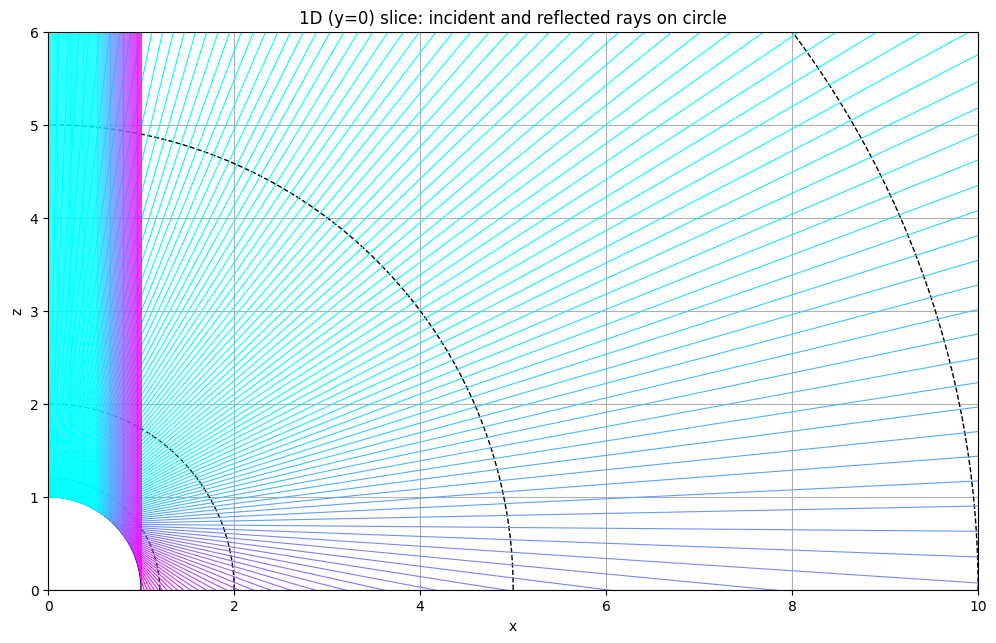

Total samples: 10001
Total samples: 10001
Total samples: 10001
Total samples: 10001


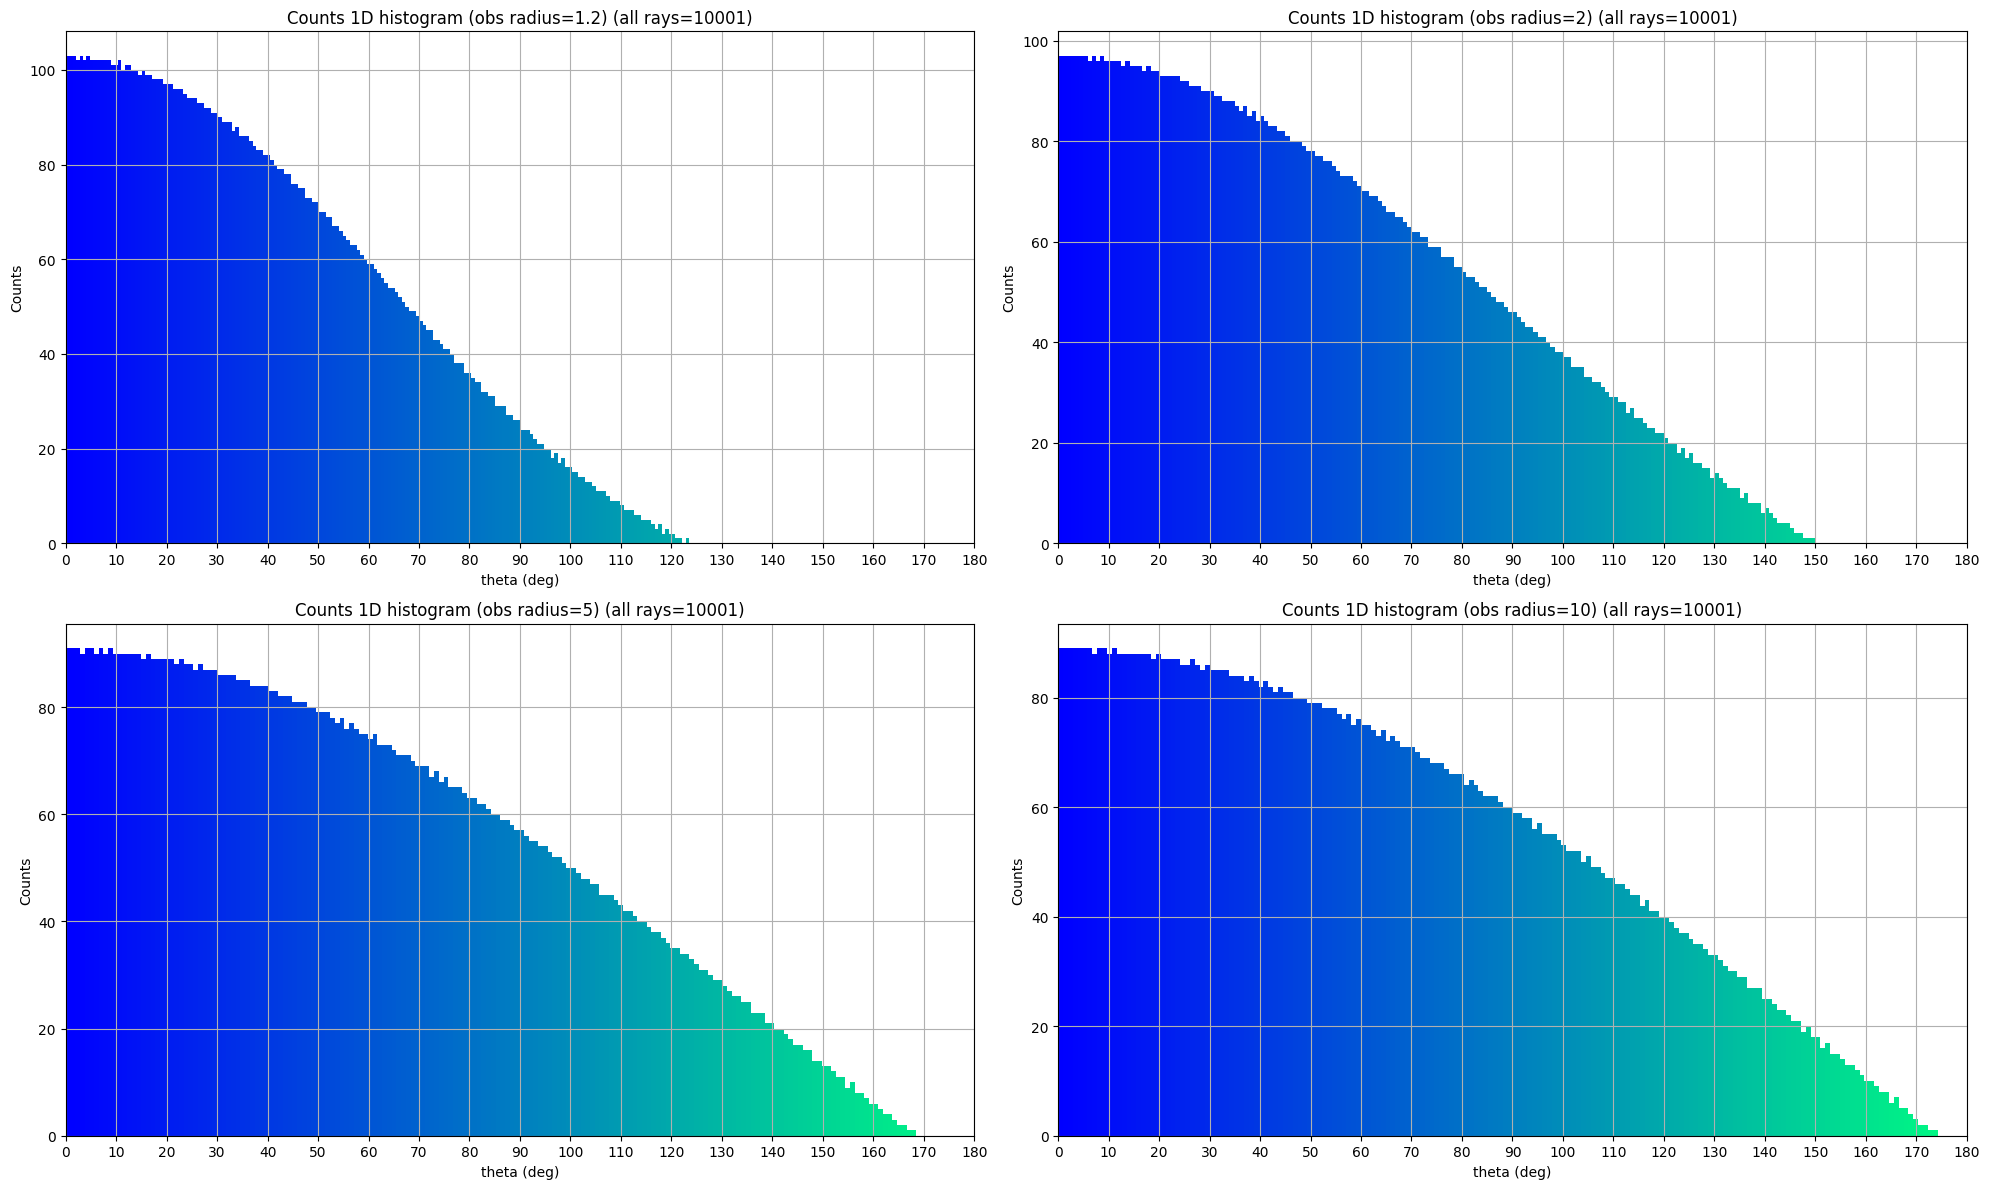

In [6]:
# ----------------------------------------
# 基本パラメータ
# ----------------------------------------
R = 1.0
step = 0.0001
xs = np.arange(0, R+step, step)

d = np.array([0.0, 0.0, -1.0])  # 入射方向
Z0 = 1000.0

R2s = [1.2,2,5,10] # 観測点の半径のリスト

# ------------------------------------------------------
# 描画の準備
# ------------------------------------------------------

fig, ax = plt.subplots(figsize=(12,8))

# 円（x-z平面）
theta = np.linspace(0, 2*np.pi, 400)
circle_x = R * np.cos(theta)
circle_z = R * np.sin(theta)
ax.plot(circle_x, circle_z, 'k', linewidth=1)

for R2 in R2s:
    circle_x2 = R2 * np.cos(theta)
    circle_z2 = R2 * np.sin(theta)
    ax.plot(circle_x2, circle_z2, 'k', linewidth=1, linestyle="--")

# カラーマップ
cmap_in = plt.get_cmap("cool")
cmap_ref = plt.get_cmap("cool")

cmap_hist = plt.get_cmap("winter")

# ------------------------------------------------------
# 描画1:光線の図示
# ------------------------------------------------------

L = 15.0 * R  # 反射線の長さスケール
step_plot = max(1, len(xs)//100)  # 多すぎないように間引き
for i in range(0, len(xs), step_plot):

    ic = (i - len(p_hits)//2) / (len(p_hits)//2)

    p0 = p0s[i]
    p = p_hits[i]
    r = ref_dirs[i]
    # 入射線（p0 -> p）
    ax.plot([p0[0], p[0]], [p0[2], p[2]], color=cmap_in(int(ic * cmap_in.N)), alpha=0.8, linewidth=0.8)
    # 反射線（p -> p + L * r）
    ax.plot([p[0], p[0] + L*r[0]], [p[2], p[2] + L*r[2]], color=cmap_ref(int(ic * cmap_ref.N)), alpha=1, linewidth=0.8)

ax.set_aspect('equal')
ax.set_xlim(0, 10*R)
ax.set_ylim(0, 6*R)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_title(f'1D (y=0) slice: incident and reflected rays on circle')
ax.grid(True)

plt.savefig(fp + f"inc_ref_rays_Rmix.png")
plt.show()

# ------------------------------------------------------
# 描画2:角度分布
# ------------------------------------------------------

fig, ax = plt.subplots(2,2, figsize=(20,12))

i = 0

for R2 in R2s:
    theta_arr_r2, phi_arr_r2, p0s, p2s, p_hits, ref_dirs = ref_rays_count(R2, xs, d, Z0, R)
    assert abs_check_r2(R2, p2s), f"R2={R2}: 観測点の距離誤差が閾値を超えました。"

    ax[i//2, i%2].grid()
    ax[i//2, i%2].set_xticks(np.arange(0,181,10))

    ax[i//2, i%2].set_title(f"Counts 1D histogram (obs radius={R2}) (all rays={samp})")
    ax[i//2, i%2].set_xlabel("theta (deg)")
    ax[i//2, i%2].set_ylabel("Counts")
    n, bins, patches = ax[i//2, i%2].hist(theta_arr_r2, bins=180, color="blue")
    ax[i//2, i%2].set_xlim(0, 180)
    for j in range(len(patches)):
        patches[j].set_facecolor(cmap_hist(bins[j] / 180))

    i += 1

plt.tight_layout()
plt.savefig(fp + f"theta_hist_Rmix.png")
plt.show()

### yの幅を持たせる
### いちいち計算しとると時間かかるのでnetCDF形式で保存

In [27]:
import xarray as xr
import tqdm

fp_nc = "./nc_underground/"

y_array = np.arange(-1,1,step*20)
make_R2 = 1000000

for y in tqdm.tqdm(y_array):
    theta_arr_r2, phi_arr_r2, p0s, p2s, p_hits, ref_dirs = ref_rays_count(make_R2, xs, d, Z0, R, y=y, print_info=False)
    assert abs_check_r2(make_R2, p2s), f"R2={make_R2}: 観測点の距離誤差が閾値を超えました。"
    ds = xr.Dataset(
        {
            "theta": (("x"), theta_arr_r2),
            "phi": (("x"), phi_arr_r2),
        },
        coords={
            "x": np.array([x[0] for x in p_hits]),  # 反射点のx座標
            "y": y,
        }
    )
    if y == y_array[0]:
        ds_all = ds
    else:
        ds_all = xr.concat([ds_all, ds], dim="y", join="outer")

ds_all.to_netcdf(fp_nc + f"reflected_rays_R2_{make_R2}.nc")

100%|██████████| 1000/1000 [04:37<00:00,  3.61it/s]


### netCDF形式ファイルを読み込み

In [137]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# read_r2 = 1.2 or 2 or 5 or 10 or 1000000
R2 = 1.2

fp_nc = "./nc_underground/"

# reflected_rays_R2_{R2}.ncが存在するかチェック
if not os.path.exists(fp_nc + f"reflected_rays_R2_{R2}.nc"):
    raise FileNotFoundError(f"{fp_nc}reflected_rays_R2_{R2}.nc does not exist")
else:
    ds_all = xr.open_dataset(fp_nc + f"reflected_rays_R2_{R2}.nc")
    print(f"reflected_rays_R2_{R2}.nc loaded correctly.")

reflected_rays_R2_1.2.nc loaded correctly.


### xarray から二次元ヒートマップ

ここでは 2 通りの方法を示します。
- グリッド化された `DataArray`（例: `ds_all['theta']` の次元が `y × n`）をそのままヒートマップ表示。
- 散布データ（`theta`・`phi`）から θ×φ の 2D ヒストグラムを作ってヒートマップ表示。

用途に応じてどちらかを使ってください。

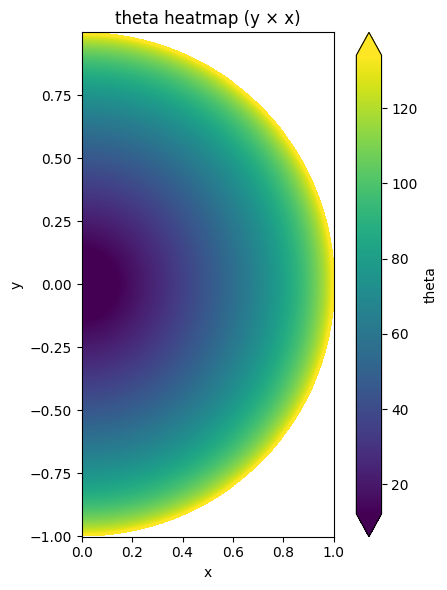

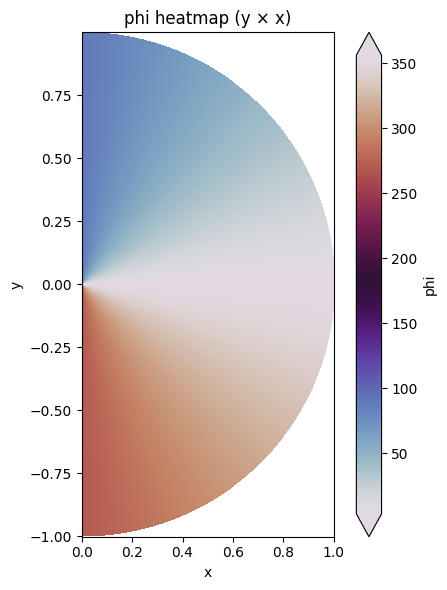

In [45]:
# その1: グリッド DataArray をそのままヒートマップ表示（y × n）
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ds_all['theta'] は次元 (y, x) の 2D になっているはずです
# NaN は自動的にマスクされます
plt.figure(figsize=(5, 6))
ds_all["theta"].plot.imshow(x="x", y="y", origin="lower", cmap="viridis", robust=True)
plt.gca().set_aspect("equal")
plt.title("theta heatmap (y × x)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig(fp + f"heatmap_theta_coordinates_R{R2}.png")
plt.show()

plt.figure(figsize=(5, 6))
ds_all["phi"].plot.imshow(x="x", y="y", origin="lower", cmap="twilight", robust=True)
plt.gca().set_aspect("equal")
plt.title("phi heatmap (y × x)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig(fp + f"heatmap_phi_coordinates_R{R2}.png")
plt.show()

In [75]:
# その2: θ×φ の 2D ヒストグラムを作ってヒートマップ表示（全 y で集計）
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

fp = "./output/"

# 1) 値を 1 次元にフラット化
theta_vals = ds_all["theta"].values.ravel()
phi_vals = ds_all["phi"].values.ravel()

# 2) 欠損除去
mask = np.isfinite(theta_vals) & np.isfinite(phi_vals)
theta_vals = theta_vals[mask]
phi_vals = phi_vals[mask]

# 3) ビン定義（必要に応じて解像度を変更）
theta_bins = np.linspace(0, 180, 181)  # θ[deg]
phi_bins = np.linspace(0, 360, 361)    # φ[deg]

# 4) 2D ヒストグラム（x: φ, y: θ）
H, phi_edges, theta_edges = np.histogram2d(phi_vals, theta_vals, bins=[phi_bins, theta_bins])

# 5) 中心座標を作る
theta_centers = 0.5 * (theta_edges[:-1] + theta_edges[1:])
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])

# 6) xarray DataArray 化（プロットしやすくするため）
heat_da = xr.DataArray(
    H.T,  # θ を縦軸にしたいので転置
    coords={"theta": theta_centers, "phi": phi_centers},
    dims=("theta", "phi"),
    name="counts",
)

# 7) 描画
"""
plt.figure(figsize=(10, 6))
heat_da.plot.imshow(x="theta", y="phi", origin="lower", cmap="inferno")
plt.xlabel("θ (deg)")
plt.ylabel("φ (deg)")
plt.title(f"2D histogram: counts over φ × θ (all y) R={R2}")
plt.tight_layout()
plt.savefig(fp + f"2dhist_theta_vs_phi_R{R2}.png")
plt.show()
"""
# 球面の面積要素$dS=\sin\theta d\theta d\phi$より、$\sin\theta$で割る


# 補足: xhistogram を使うと遅延計算や Dask と相性良く書けます。
# from xhistogram.xarray import histogram
# heat_da2 = histogram(ds_all['phi'], ds_all['theta'], bins=[phi_bins, theta_bins])
# heat_da2 = heat_da2.rename({'phi_bin': 'phi', 'theta_bin': 'theta'}).transpose('theta','phi')
# heat_da2.plot.imshow(x='phi', y='theta', origin='lower', aspect='auto', cmap='inferno')

'\nplt.figure(figsize=(10, 6))\nheat_da.plot.imshow(x="theta", y="phi", origin="lower", cmap="inferno")\nplt.xlabel("θ (deg)")\nplt.ylabel("φ (deg)")\nplt.title(f"2D histogram: counts over φ × θ (all y) R={R2}")\nplt.tight_layout()\nplt.savefig(fp + f"2dhist_theta_vs_phi_R{R2}.png")\nplt.show()\n'

### 立体角で補正
$$
dS = \sin\theta d\theta d\phi
$$
より、$\sin\theta$で割る

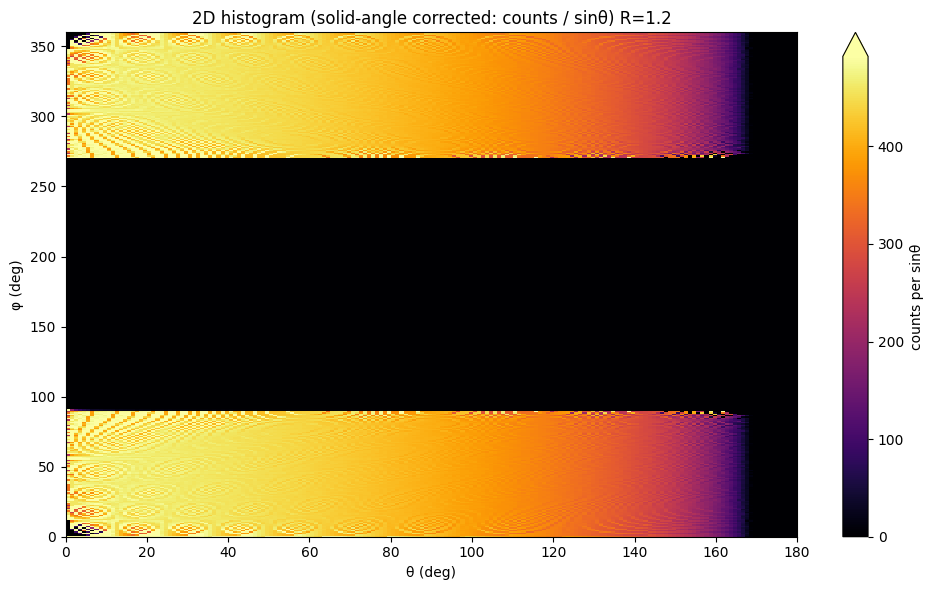

In [138]:
ste_da = heat_da / np.sin(np.radians(heat_da["theta"]))
ste_da.name = "counts per sinθ"

plt.figure(figsize=(10, 6))
ste_da.plot.imshow(x="theta", y="phi", origin="lower", cmap="inferno", robust=True)
plt.xlabel("θ (deg)")
plt.ylabel("φ (deg)")
plt.title(f"2D histogram (solid-angle corrected: counts / sinθ) R={R2}")
plt.tight_layout()
#plt.savefig(fp + f"2dhist_theta_vs_phi_counts_per_sin_theta_R{R2}.png")
#plt.show()

#### $0 \le \phi \le 90$において積分して、$\theta$について一次元化する
Copilotくんに投げて出てきたやつをちょい改良

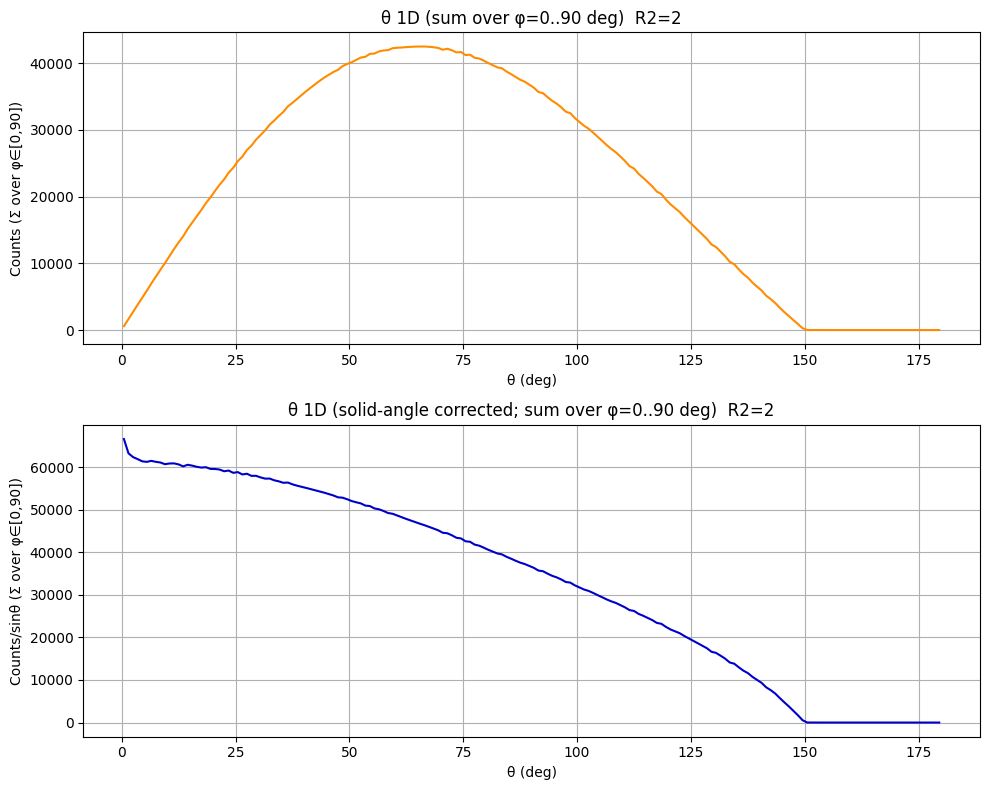

In [8]:
# φ が 0〜90 [deg] の範囲で、θ ごとに和を取って 1D 化

if "heat_da" not in globals():
    raise NameError("heat_da が見つかりません。先に 2D ヒストグラムを作るセル（heat_da 定義）を実行してください。")

phi_min, phi_max = 0.0, 90.0

# counts（未補正）
heat_phi_0_90 = heat_da.where((heat_da["phi"] >= phi_min) & (heat_da["phi"] <= phi_max), drop=True)
theta_1d_counts_phi_0_90 = heat_phi_0_90.sum("phi")
theta_1d_counts_phi_0_90.name = "counts (sum over phi 0-90)"

# counts/sinθ（立体角補正）も同様に
if "ste_da" in globals():
    ste_phi_0_90 = ste_da.where((ste_da["phi"] >= phi_min) & (ste_da["phi"] <= phi_max), drop=True)
    theta_1d_ste_phi_0_90 = ste_phi_0_90.sum("phi")
    theta_1d_ste_phi_0_90.name = "counts/sinθ (sum over phi 0-90)"
else:
    theta_1d_ste_phi_0_90 = None

# プロット
fig, ax = plt.subplots(2,1,figsize=(10, 8))
ax[0].plot(theta_1d_counts_phi_0_90["theta"].values, theta_1d_counts_phi_0_90.values, lw=1.5, c="darkorange")
ax[0].set_xlabel("θ (deg)")
ax[0].set_ylabel("Counts (Σ over φ∈[0,90])")
ax[0].set_title(f"θ 1D (sum over φ={phi_min:.0f}..{phi_max:.0f} deg)  R2={R2}")
ax[0].grid(True)

if theta_1d_ste_phi_0_90 is not None:
    ax[1].plot(theta_1d_ste_phi_0_90["theta"].values, theta_1d_ste_phi_0_90.values, lw=1.5, c="mediumblue")
    ax[1].set_xlabel("θ (deg)")
    ax[1].set_ylabel("Counts/sinθ (Σ over φ∈[0,90])")
    ax[1].set_title(f"θ 1D (solid-angle corrected; sum over φ={phi_min:.0f}..{phi_max:.0f} deg)  R2={R2}")
    ax[1].grid(True)

plt.tight_layout()
plt.savefig(fp + f"phi_sum_{phi_min}_{phi_max}_R{R2}.png")
plt.show()

### 反射率を導入
入射角$\theta$とすると、

In [5]:
def get_reflection_rate(d, n, e0, e1):
    theta_s = np.arccos(np.dot(d,-n)) # 入射角

    # 真空から第一層への屈折角   田中M論 式(2.9) スネルの法則
    theta_I =  np.arccos(np.sqrt(1-e0/e1*(np.sin(theta_s))**2))


    # 反射率の計算 (田中M論より)
    Rtm = np.tan(theta_s-theta_I)/np.tan(theta_s+theta_I) # TMモード
    Rte = -np.sin(theta_s-theta_I)/np.sin(theta_s+theta_I) # TEモード

    Rave = (abs(Rtm) + abs(Rte)) / 2

    return Rtm, Rte, Rave, theta_s

def get_reflection_rate_angle(theta_s, e0, e1):

    # theta_sのデータ型がfloatの場合とnp.arrayの場合で分岐
    if isinstance(theta_s, float):

        # 真空から第一層への屈折角   田中M論 式(2.9) スネルの法則
        theta_I =  np.arccos(np.sqrt(1-e0/e1*(np.sin(theta_s))**2))


        # 反射率の計算 (田中M論より)
        Rtm = np.tan(theta_s-theta_I)/np.tan(theta_s+theta_I) # TMモード
        Rte = -np.sin(theta_s-theta_I)/np.sin(theta_s+theta_I) # TEモード

        Rave = (abs(Rtm) + abs(Rte)) / 2

    elif isinstance(theta_s, np.ndarray):
        
        Rtm_list = []
        Rte_list = []
        Rave_list = []

        for th_s in theta_s:
            # 真空から第一層への屈折角   田中M論 式(2.9) スネルの法則
            theta_I =  np.arccos(np.sqrt(1-e0/e1*(np.sin(th_s))**2))


            # 反射率の計算 (田中M論より)
            Rtm = np.tan(th_s-theta_I)/np.tan(th_s+theta_I) # TMモード
            Rte = -np.sin(th_s-theta_I)/np.sin(th_s+theta_I) # TEモード

            Rave = (abs(Rtm) + abs(Rte)) / 2

            Rtm_list.append(Rtm)
            Rte_list.append(Rte)
            Rave_list.append(Rave)

        Rtm = np.array(Rtm_list)
        Rte = np.array(Rte_list)
        Rave = np.array(Rave_list)

    return Rtm, Rte, Rave

def get_sc_angle(theta_s, R_moon, H_obs):
    # 入射角から探査機が捕捉する角度を計算
    theta_al = 2.0*theta_s - np.arcsin(R_moon/(R_moon+H_obs)*(np.arcsin(theta_s)))

    return theta_al

def ref_rays_count_ref(R2, xs, d, Z0, R, y=0.0, print_info=True, reflectance=False, e1=3.0):

    theta_list = []
    phi_list = []
    p0s = []
    p2s = []
    ref_dirs = []

    ts = []

    p_hits = []

    rs = []

    amps = []

    alps = []

    for x in xs:
        p0 = np.array([x, y, Z0])

        a = np.dot(d, d)
        b = 2 * np.dot(p0, d)
        c = np.dot(p0, p0) - R*R
        D = b*b - 4*a*c

        if D < 0:
            continue

        t = (-b - np.sqrt(D)) / (2*a)
        if t < 0:
            continue

        p = p0 + t * d  # 反射点の位置ベクトル
        n = p / np.linalg.norm(p)
        r = d - 2*np.dot(d, n)*n
        r /= np.linalg.norm(r) # 反射光の方向ベクトル(外側へ向かう方向を正)
        rs.append(r)

        ts.append(t)

        a2 = np.dot(r, r)
        b2 = 2 * np.dot(p, r)
        c2 = np.dot(p, p) - R2*R2
        D2 = b2*b2 - 4*a2*c2

        if D2 < 0:
            continue

        t2 = (-b2 + np.sqrt(D2)) / (2*a2)
        if t2 < 0:
            continue

        p2 = p + t2 * r # 観測球面との交点
        p2_n = p2 / np.linalg.norm(p2)  # 単位ベクトル化

        theta = np.arccos(p2_n[2])
        phi = np.arctan2(p2_n[1], p2_n[0])
        if phi < 0:
            phi += 2*np.pi

        theta_deg = np.degrees(theta)
        phi_deg = np.degrees(phi)

        p0s.append(p0)
        p2s.append(p2)
        p_hits.append(p)
        ref_dirs.append(r)
        theta_list.append(theta_deg)
        phi_list.append(phi_deg) # y=0では当然0 or pi

        # ----------------------------------------
        # 反射率計算

        e0 = 1.0

        if reflectance == 1:
            Rtm, Rte, Rave, theta_s = get_reflection_rate(d,n,e0,e1)

            theta_al = get_sc_angle(theta_s, R, R2 - R)

            amps.append([Rtm,Rte,Rave])
            alps.append(theta_al)

        # ----------------------------------------

    assert len(amps) == len(alps), "リストの要素数が一致しません"

    theta_arr_r2 = np.array(theta_list)
    phi_arr_r2 = np.array(phi_list)
    amp_arr = np.array(amps)
    alp_arr = np.array(alps)

    samp = len(theta_arr_r2)

    if print_info:
        print("Total samples:", samp)

    return theta_arr_r2, phi_arr_r2, p0s, p2s, p_hits, ref_dirs, amp_arr, alp_arr

def get_default_param(target):

    match target:
        case "moon":
            H_obs = 100e3       # 観測者の高度[m] (Kaguya)
            D_moon = 1*1e3      # 表層から地下構造までのレゴリスリス層(第一層)の厚さ[m]
            R_moon = 1737400.0  # 月の半径[m]
            e1 = 4.0            # レゴリス層(第一層)の比誘電率
            e2 = 8.0            # レゴリス層の下の地下構造(第二層)の比誘電率
            tandelta = 0.0125   # レゴリス層(第一層)の損失角

        case "ganymede":
            H_obs = 500e3       # 観測者の高度[m] (JUICE)
            D_moon = 1*1e3      # 表層から地下構造までのレゴリスリス層(第一層)の厚さ[m]
            R_moon = 5268000.0/2.0  # ガニメデの半径[m]
            e1 = 3.0            # 第一層の比誘電率
            e2 = 87.0           # 第二層の比誘電率
            tandelta = 0.0      # 第一層の損失角
    
    return e1, e2, H_obs, D_moon, R_moon, e1, e2, tandelta

### 反射率のイメージを描画

/tmp/ipykernel_84665/2951991104.py:9: RuntimeWarning: invalid value encountered in scalar divide
  Rtm = np.tan(theta_s-theta_I)/np.tan(theta_s+theta_I) # TMモード
/tmp/ipykernel_84665/2951991104.py:10: RuntimeWarning: invalid value encountered in scalar divide
  Rte = -np.sin(theta_s-theta_I)/np.sin(theta_s+theta_I) # TEモード


/tmp/ipykernel_84665/2951991104.py:60: RuntimeWarning: invalid value encountered in arcsin
  theta_al = 2.0*theta_s - np.arcsin(R_moon/(R_moon+H_obs)*(np.arcsin(theta_s)))


Total samples: 10001


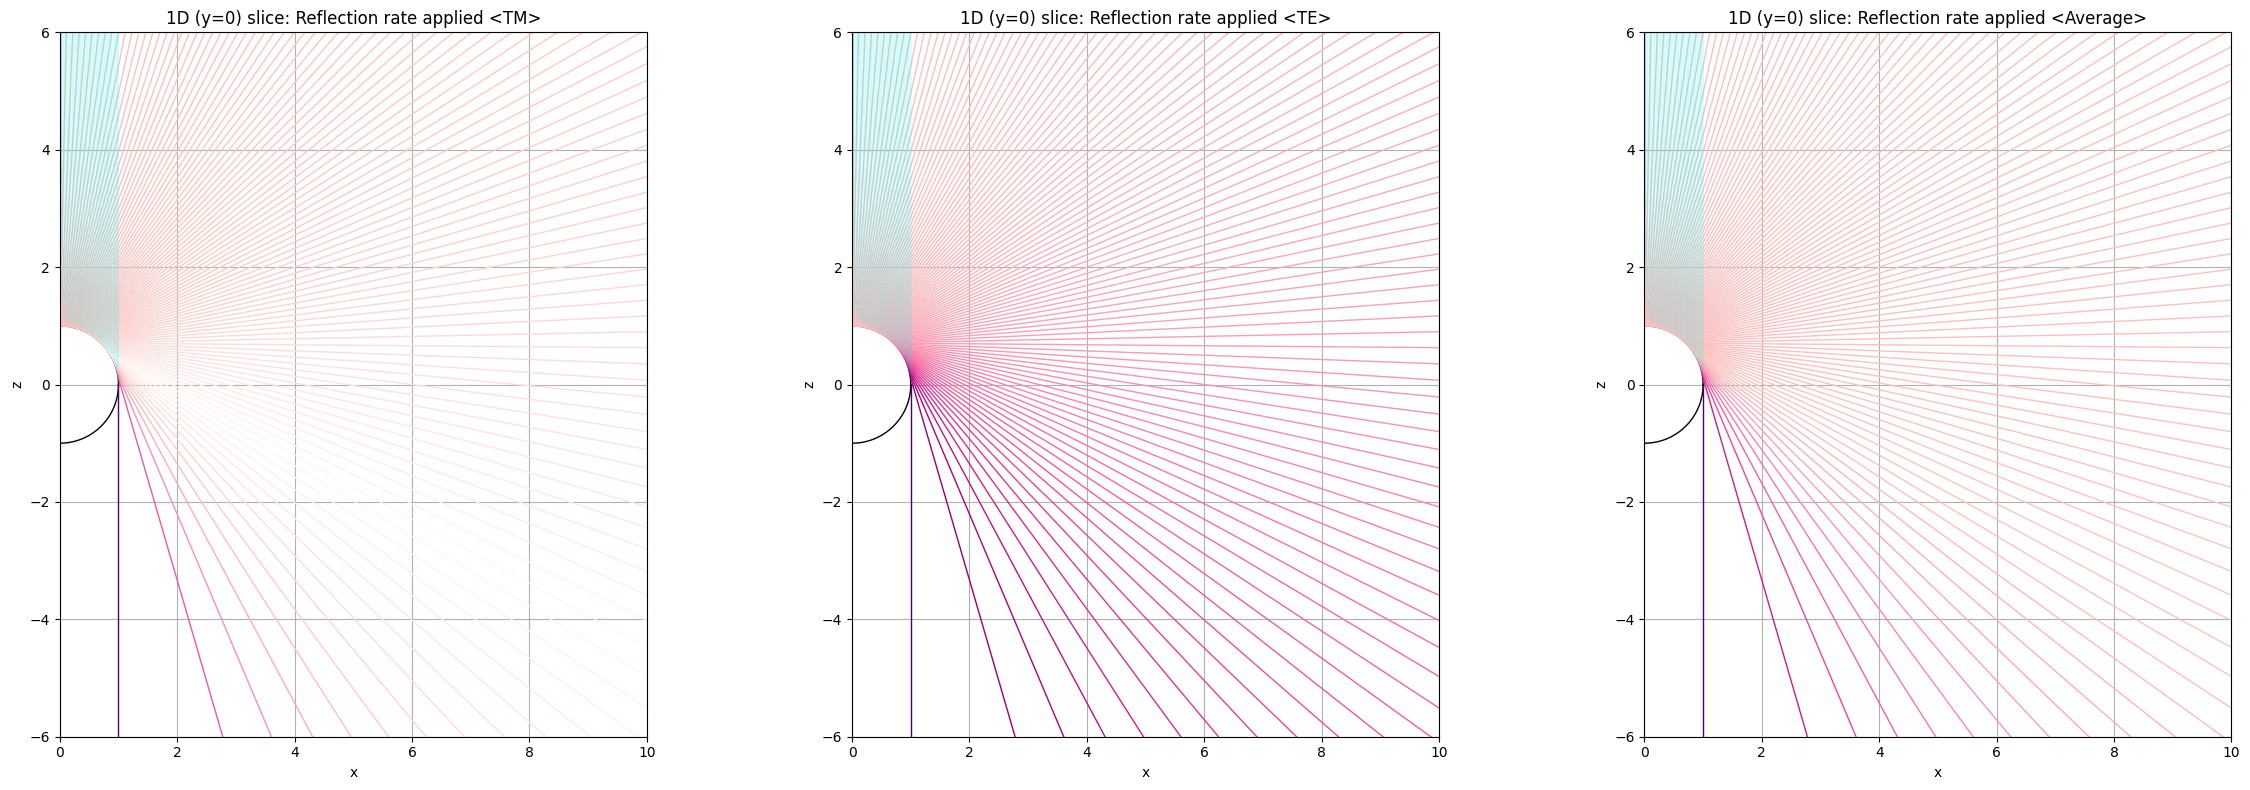

In [44]:
# パラメータ設定 e0: 真空の誘電率, e1: 氷層の誘電率
target = "ganymede" # "moon" or "ganymede"

e1, e2, H_obs, D_moon, R_moon, e1, e2, tandelta = get_default_param(target)

theta_arr_r2, phi_arr_r2, p0s, p2s, p_hits, ref_dirs, amp_arr, alp_arr = ref_rays_count_ref(R2, xs, d, Z0, R, reflectance=True, e1=e1)

fig, ax = plt.subplots(1, 3, figsize=(24, 8))

# カラーマップ(反射率表現用)
cmap_in_rate = plt.get_cmap("RdPu")
cmap_ref_rate = plt.get_cmap("RdPu")

words = ['TM', 'TE', 'Average']

for i in range(3):
    
    # 円（x-z平面）
    theta = np.linspace(0, 2*np.pi, 400)
    circle_x = R * np.cos(theta)
    circle_z = R * np.sin(theta)
    ax[i].plot(circle_x, circle_z, 'k', linewidth=1)

    L = 15.0 * R  # 反射線の長さスケール
    step_plot = max(1, len(p_hits)//100)  # 多すぎないように間引き
    for ii in range(0, len(p_hits), step_plot):

        # ic = (i - len(p_hits)//2) / (len(p_hits)//2)

        p0 = p0s[ii]
        p = p_hits[ii]
        r = ref_dirs[ii]

        a = np.absolute(amp_arr[ii][i])
        w = words[i]
        # alpha を安全な範囲 [0,1] にクリップし、非有限値を置換
        a = np.nan_to_num(a, nan=1.0, posinf=1.0, neginf=0.0)
        a = float(np.clip(a, 0.0, 1.0))

        # 入射線（p0 -> p）
        ax[i].plot([p0[0], p[0]], [p0[2], p[2]], color="cyan", alpha=0.1, linewidth=0.8)
        # 反射線（p -> p + L * r）
        ax[i].plot(
            [p[0], p[0] + L*r[0]],
            [p[2], p[2] + L*r[2]],
            color=cmap_ref_rate(int(a * (cmap_ref_rate.N - 1))),
            alpha=1,
            linewidth=1
        )

        ax[i].set_aspect('equal')
        ax[i].set_xlim(0, 10*R)
        ax[i].set_ylim(-6*R, 6*R)
        ax[i].set_xlabel('x')
        ax[i].set_ylabel('z')
        ax[i].set_title(f'1D (y=0) slice: Reflection rate applied <{w}>')
        ax[i].grid(True)

plt.tight_layout()
plt.savefig(fp + f"inc_ref_rays_rate_{target}.png")
plt.show()

### 反射率をかける (無限遠のみ横軸の半分$\simeq$入射角よりそのまま計算可)

netCDF形式で保存されたalpha to theta_sの表からinc_angleに対応するtheta_sを取得

In [139]:
att_da = xr.open_dataarray(fp_nc + "alpha_to_theta_forhist.nc")

if R2 != 1000000:
    inc_angle = att_da.sel(H=R2, method="nearest")
else:
    inc_angle = ste_da["theta"]/2

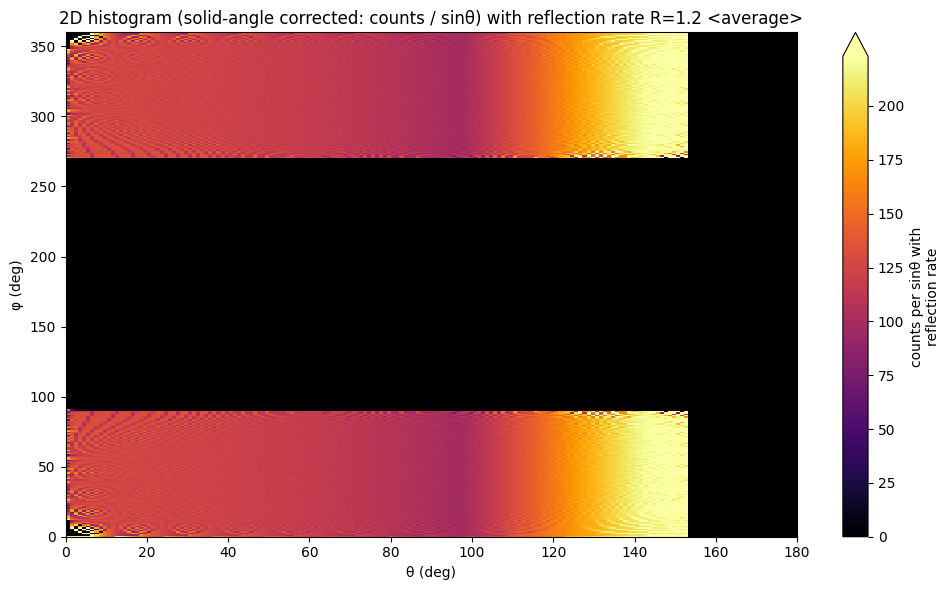

In [149]:
target = "ganymede" # "moon" or "ganymede"

e1, e2, H_obs, D_moon, R_moon, e1, e2, tandelta = get_default_param(target)

Rtm, Rte, Rave = get_reflection_rate_angle(np.radians(inc_angle.values), e0=1.0, e1=e1)

# ste_da の theta 軸に対して Rave をかけ合わせる（xarray の次元名でブロードキャストさせる）
Rave_da = xr.DataArray(Rave, coords={"theta": ste_da["theta"]}, dims=("theta",))
Rave_da = Rave_da.where(Rave_da <= 1, 0) # 反射率1以上を0でマスク(予期しない挙動防止)

Rte_da = xr.DataArray(Rte, coords={"theta": ste_da["theta"]}, dims=("theta",))
Rte_da = Rte_da.where(Rte_da <= 1, 0) # 反射率1以上を0でマスク(予期しない挙動防止)

Rtm_da = xr.DataArray(Rtm, coords={"theta": ste_da["theta"]}, dims=("theta",))
Rtm_da = Rtm_da.where(Rtm_da <= 1, 0) # 反射率1以上を0でマスク(予期しない挙動防止)

apply_ref = "average" # "average" or "TE" or "TM"

if apply_ref == "average":
    use_ref_da = Rave_da
elif apply_ref == "TE":
    use_ref_da = Rte_da
elif apply_ref == "TM":
    use_ref_da = Rtm_da
else:
    raise ValueError("Invalid apply_ref value. Choose from 'average', 'TE', or 'TM'.")

# xarray.DataArray には .abs() は無いので、Python の abs()（= DataArray.__abs__）を使う
ste_da_ref = (ste_da * abs(use_ref_da)).rename("counts per sinθ with reflection rate")

plt.figure(figsize=(10, 6))
ste_da_ref.plot.imshow(x="theta", y="phi", origin="lower", cmap="inferno", robust=True)
plt.xlabel("θ (deg)")
plt.ylabel("φ (deg)")
plt.title(f"2D histogram (solid-angle corrected: counts / sinθ) with reflection rate R={R2} <{apply_ref}>")
plt.tight_layout()
#plt.savefig(fp + f"2dhist_theta_vs_phi_counts_per_sin_theta_w_ref_R{R2}_{apply_ref}.png")
#plt.show()

### 探査機軌道に垂直な方向で補正
$\cos\theta$($= \bf{r} \cdot \bf{n}$)で割る

In [150]:
p2s_norm = np.array(np.linalg.norm(p2s, axis=1))
p2s_norm_true = np.full(len(p2s), p2s_norm[0])
ths = 1e-6
costh = np.empty(len(p2s))

if np.all(p2s_norm - p2s_norm_true < ths):
    p2s_normed = np.array([p2s[x]/p2s_norm[0] for x in range(len(p2s))])
    print("p2sが正常に単位ベクトル化できました")
    for x in range(len(p2s)):
        costh[x] = np.dot(p2s_normed[x], ref_dirs[x])
else:
    print("p2sの距離が一定ではありません")

ve_da = ste_da_ref.copy()

axis_theta = []
# 配列同士の範囲判定は「比較の連鎖」にならないように、括弧 + &（または np.logical_and）で書く
# histのbinの範囲内にいるデータ間の平均でbinを代表させる
for i in range(len(ve_da["theta"].values)):
    m_min = ve_da["theta"].values[i] - 0.5
    m_max = ve_da["theta"].values[i] + 0.5

    mask = np.logical_and((theta_arr_r2 < m_max),(theta_arr_r2 >= m_min))
    if np.any(mask) == False:
        ave_cos = np.nan
    else:
        ave_cos = np.average(costh[mask])

    axis_theta.append(ave_cos)

axis_theta = np.array(axis_theta)

axt_da = xr.DataArray(axis_theta, coords={"theta": ve_da["theta"]})
axt_da.name = "cos"

p2sが正常に単位ベクトル化できました


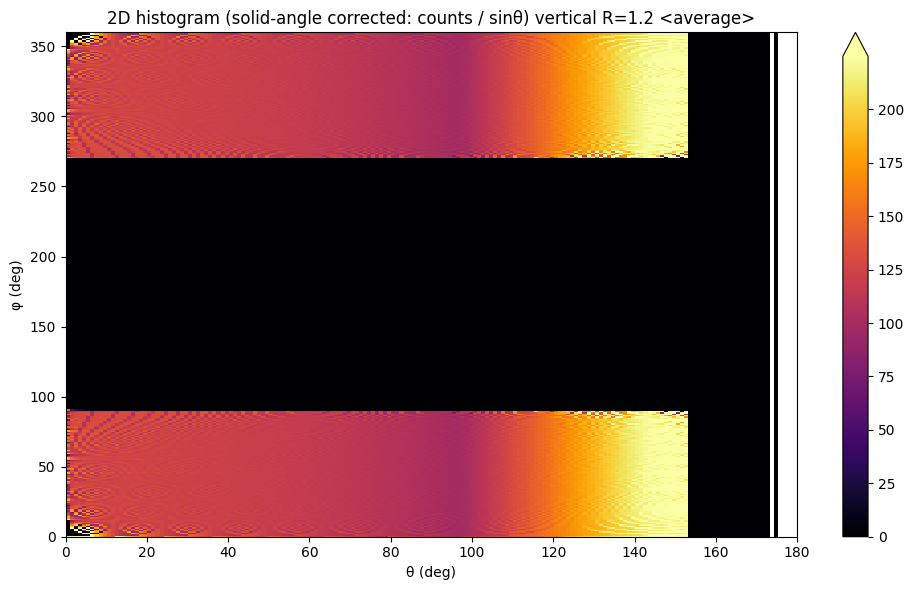

In [151]:
ve_da = ve_da / axt_da

ve_da.fillna(0)

plt.figure(figsize=(10, 6))
ve_da.plot.imshow(x="theta", y="phi", origin="lower", cmap="inferno", robust=True)
plt.xlabel("θ (deg)")
plt.ylabel("φ (deg)")
plt.title(f"2D histogram (solid-angle corrected: counts / sinθ) vertical R={R2} <{apply_ref}>")
plt.tight_layout()
plt.savefig(fp + f"2dhist_ref_rate_vertical_R{R2}_{apply_ref}.png")
plt.show()

In [9]:
import matplotlib.pyplot as plt

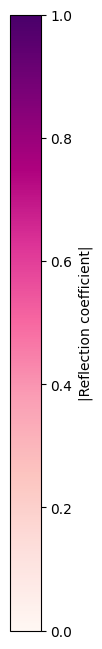

In [33]:
cmap_ref_rate = plt.get_cmap("RdPu")
fp = "./output/"

fig = plt.figure(figsize=(10,8))
#fig.patch.set_facecolor('antiquewhite')
ax = fig.add_subplot(111)
norm = plt.Normalize(vmin=0.0, vmax=1.0)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_ref_rate)
sm.set_array([])

cb_fig = fig.colorbar(sm, ax=ax, fraction=0.2, pad=0.02, label="|Reflection coefficient|")
fig.delaxes(ax)
#fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig(fp + "colorbar_ref_rate.png")
plt.show()

In [ ]:
stref_da = ste_da / np.absolute(amp_arr)

### エネルギーに換算
木星電波 : $3 \times 10^{-15} [\mathrm{Wm^{-2}Hz^{-1}}]$